In [2]:
#Name: Pavani Chavali
#Course: Advanced Big Data and Data Mining
#Assignment: Lab 2 – Exploring K-Nearest Neighbors and Radius Neighbors Classifiers

In [5]:
!mamba install pandas
!mamba install scikit-learn
%pip install scikit-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier, RadiusNeighborsClassifier
from sklearn.metrics import accuracy_score
import warnings

mambajs 0.21.4

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 1.607 seconds
All requested packages already installed.
mambajs 0.21.4

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, scikit-learn
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 0.880 seconds
  Name                Version    Build                Channel
---------------------------------------------------------------------------
+ brotli-python       1.2.0      py313ha26e73d_2      emscripten-forge-4x
+ certifi             2026.6.17  pyhd8ed1ab_0         conda-forge
+ charset-normalizer  3.4.9      pyhd8ed1ab_0         conda-forge
+ idna                3.18       pyhcf101f3_0         conda-forge
+ joblib              1.5.3      py313h1804a44_3      emscripten-forge-4x
+ narwhals            2.24.0     pyhcf101f3_0         co

In [6]:
# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

In [11]:
############ STEP:1 ##############
# 1. Load the Wine Dataset
wine_data = load_wine()
X = pd.DataFrame(wine_data.data, columns=wine_data.feature_names)
y = wine_data.target

In [8]:
# 2. Perform basic data exploration
print("--- Data Exploration ---")
print(f"Dataset Shape: {X.shape[0]} samples, {X.shape[1]} features.")
print("\nFirst 5 rows of the dataset:")
display(X.head())

--- Data Exploration ---
Dataset Shape: 178 samples, 13 features.

First 5 rows of the dataset:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [9]:
print("\nClass Distribution:")
class_counts = pd.Series(y).value_counts().sort_index()
for class_label, count in class_counts.items():
    print(f"Class {class_label} ({wine_data.target_names[class_label]}): {count} samples")


Class Distribution:
Class 0 (class_0): 59 samples
Class 1 (class_1): 71 samples
Class 2 (class_2): 48 samples


In [10]:
# 3. Split the dataset (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTraining set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")


Training set size: 142 samples
Testing set size: 36 samples


In [12]:
############ STEP:2 ##############
# Initialize a list of k values to evaluate
k_values = [1, 5, 11, 15, 21]
knn_accuracies = []

print("--- KNN Classifier Results ---")

--- KNN Classifier Results ---


In [13]:
for k in k_values:
    # Instantiate and train the KNN model
    knn_model = KNeighborsClassifier(n_neighbors=k)
    knn_model.fit(X_train, y_train)
    
    # Predict and evaluate
    y_pred_knn = knn_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred_knn)
    knn_accuracies.append(acc)
    
    print(f"Accuracy for k={k:2d}: {acc:.4f}")

Accuracy for k= 1: 0.7778
Accuracy for k= 5: 0.8056
Accuracy for k=11: 0.8056
Accuracy for k=15: 0.8056
Accuracy for k=21: 0.8056


In [14]:
############ STEP:3 ##############
# Initialize a list of radius values to evaluate
radius_values = [350, 400, 450, 500, 550, 600]
rnn_accuracies = []

In [15]:
print("--- Radius Neighbors Classifier Results ---")
for r in radius_values:
    # Instantiate and train the RNN model
    # outlier_label='most_frequent' prevents errors if a point has no neighbors within radius 'r'
    rnn_model = RadiusNeighborsClassifier(radius=r, outlier_label='most_frequent')
    rnn_model.fit(X_train, y_train)
    
    # Predict and evaluate
    y_pred_rnn = rnn_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred_rnn)
    rnn_accuracies.append(acc)
    
    print(f"Accuracy for radius={r}: {acc:.4f}")

--- Radius Neighbors Classifier Results ---
Accuracy for radius=350: 0.7222
Accuracy for radius=400: 0.6944
Accuracy for radius=450: 0.6944
Accuracy for radius=500: 0.6944
Accuracy for radius=550: 0.6667
Accuracy for radius=600: 0.6667


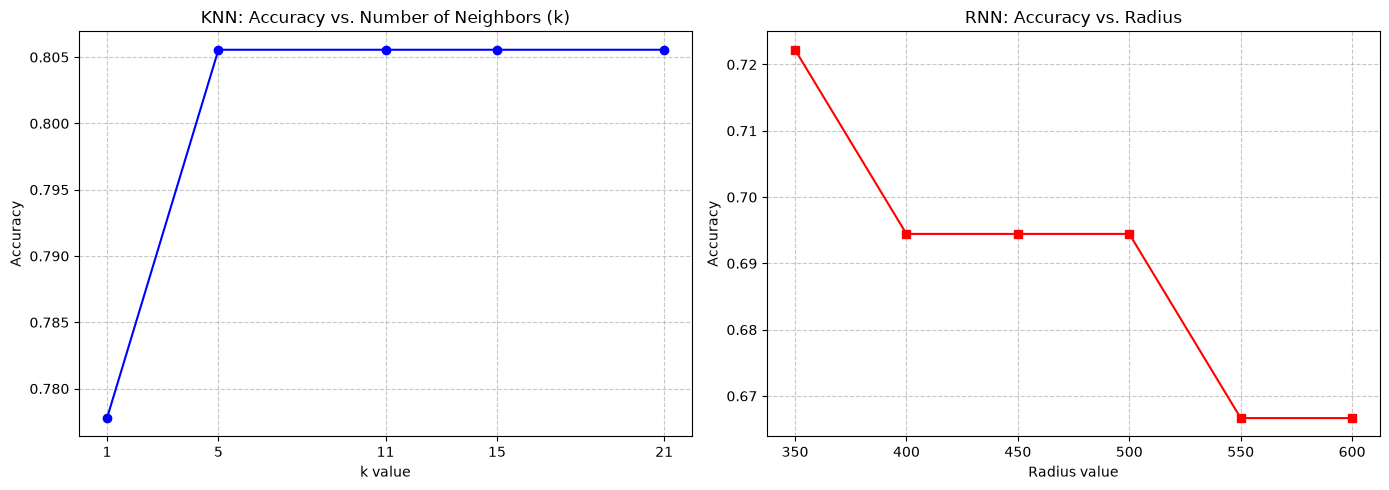

In [18]:
############ STEP:4 ##############
# Create subplots for comparative visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot KNN Accuracies
ax1.plot(k_values, knn_accuracies, marker='o', color='b', linestyle='-')
ax1.set_title('KNN: Accuracy vs. Number of Neighbors (k)')
ax1.set_xlabel('k value')
ax1.set_ylabel('Accuracy')
ax1.set_xticks(k_values)
ax1.grid(True, linestyle='--', alpha=0.7)

# Plot RNN Accuracies
ax2.plot(radius_values, rnn_accuracies, marker='s', color='r', linestyle='-')
ax2.set_title('RNN: Accuracy vs. Radius')
ax2.set_xlabel('Radius value')
ax2.set_ylabel('Accuracy')
ax2.set_xticks(radius_values)
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()